In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib


In [2]:
# 讀取數據
data_dir = '/workspaces/BO_EXPERIMENTS/src/results/20260309/decomposition_bo'
bo_files = [n for n in os.listdir(data_dir) if 'BO' in n[:2]]
theta_bo_files = [n for n in os.listdir(data_dir) if 'Decomposition' in n]
bo_paths = [os.path.join(data_dir, n) for n in bo_files]
theta_bo_paths = [os.path.join(data_dir, n) for n in theta_bo_files]

In [3]:
bo_hv_data = {}

for bo_path in bo_paths:
    data_info = joblib.load(bo_path)
    bo_hv_data[data_info['datasplit_seed']] = data_info['hv_ls']

bo_df = pd.DataFrame(bo_hv_data)

theta_hv_data = {}
for bo_path in theta_bo_paths:
    data_info = joblib.load(bo_path)
    theta_hv_data[data_info['datasplit_seed']] = data_info['hv_ls']

theta_bo_df = pd.DataFrame(theta_hv_data)

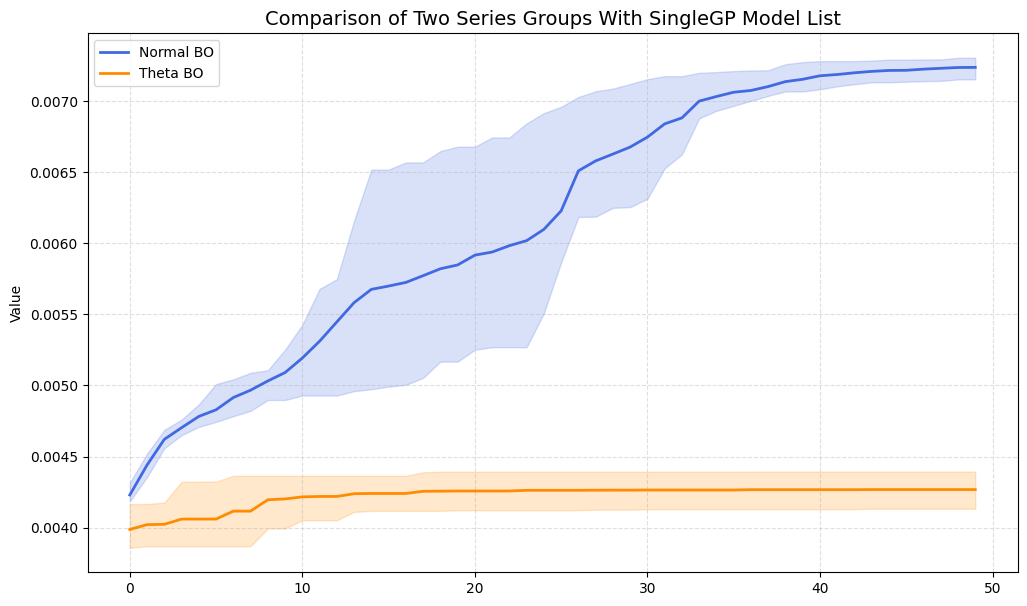

In [4]:
plt.figure(figsize=(12, 7))

# --- 第一組：藍色系 ---
plt.fill_between(range(len(bo_df)), bo_df.min(axis=1), bo_df.max(axis=1), color='royalblue', alpha=0.2)
plt.plot(range(len(bo_df)), bo_df.mean(axis=1), color='royalblue', linewidth=2, label='Normal BO')

# --- 第二組：橘色系 ---
plt.fill_between(range(len(theta_bo_df)), theta_bo_df.min(axis=1), theta_bo_df.max(axis=1), color='darkorange', alpha=0.2)
plt.plot(range(len(theta_bo_df)), theta_bo_df.mean(axis=1), color='darkorange', linewidth=2, label='Theta BO')

# 圖表優化
plt.title("Comparison of Two Series Groups With SingleGP Model List", fontsize=14)
plt.ylabel("Value")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()